# Кластеризация
### Задание.

В файле *biomedical_data_raw.csv* представлены биомедицинские данные пациентов.

Для каждого пациента измерены следующие показатели:  
- Возраст (аge)  
- Пол (gender)      
- Индекс массы тела (bmi)  
- Систолическое артериальное давление (sbp)  
- Уровень холестерина (cholesterol)  
- Группа крови (blood_type)  
- Уровень образования (education_level)  
- Стадия заболевания (disease_stage)  
- Курение (smoking)  
- Основной симптом заболевания (main_symptom)  
- Тип лечения (treatment)  

Выполните следующие задания на основе представленного датасета:

1) Проведите полный цикл предварительной обработки данных: определение типа переменных, поиск дубликатов, обработка пропущенных значений, обработка категориальных признаков, анализ выбросов, нормализация. Разделение на обучающую и тестовую выборки не требуется. Сопроводите свой анализ необходимыми графиками (боксплоты, столбчатые диаграммы). Все действия должны быть объяснены.

2) Визуализируйте данные на плоскости применив метод главных компонент (PCA). На основе графика предположите, сколько кластеров существует в данных?

3) Примените к исходным предобработанным данным (не PCA-трансформированным) алгоритм кластеризации K-means. Число кластеров нужно выбрать так, чтобы по итогу между объектами из разных кластеров существовали статистически значимые отличия в значениях некоторых переменных. То есть на этом этапе необходимо также реализовать проверку статистических гипотез для сравнения переменных между кластерами. После выбора окончательного числа кластеров визуализируйте данные на плоскости, применив PCA и изобразив точки разными цветами в зависимости от номера кластера.

4) Примените к исходным предобработанным данным (не PCA-трансформированным) функцию построения дендрограммы, используя разные методы оценки связи между кластерами. Какой метод позволяет получить более сбалансированные кластеры?

5) Примените к исходным предобработанным данным (не PCA-трансформированным) алгоритм агломеративной кластеризации с выбранным на предыдущем шаге методом оценки связи. Выберите оптимальное число кластеров на основе анализа дендрограммы и статистических различией между кластерами. После выбора окончательного числа кластеров визуализируйте данные на плоскости, применив PCA и изобразив точки разными цветами в зависимости от номера кластера.

6) Сравните результаты K-means и агломеративной кластеризации. Насколько похожие кластеры были выделены этими алгоритмами?

7) Охарактеризуйте выделенные кластеры, определите их основные особенности (например, отличия по возрасту, полу и прочее).

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

from scipy.stats import kruskal, chi2_contingency
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

sns.set_theme(style="whitegrid")

DATA_PATH = "biomedical_data_raw.csv"

1) Проведите полный цикл предварительной обработки данных: определение типа переменных, поиск дубликатов, обработка пропущенных значений, обработка категориальных признаков, анализ выбросов, нормализация. Разделение на обучающую и тестовую выборки не требуется. Сопроводите свой анализ необходимыми графиками (боксплоты, столбчатые диаграммы). Все действия должны быть объяснены.

In [2]:
# Загружаем данные

df_raw = pd.read_csv(DATA_PATH)
print("Размер датасета (строки, столбцы):", df_raw.shape)

df_raw.head()

Размер датасета (строки, столбцы): (612, 12)


,patient_id,age,gender,bmi,sbp,cholesterol,blood_type,education_level,disease_stage,smoking,main_symptom,treatment
0,PAT_0001,37,М,22.5,103.0,4.17,A,NaN,I,нет,слабость,консервативное
1,PAT_0002,34,М,22.7,106.0,4.68,B,NaN,II,NaN,слабость,NaN
2,PAT_0003,38,Ж,20.6,116.0,3.71,A,1.0,II,нет,температура,NaN
3,PAT_0004,42,Ж,22.5,115.0,4.45,O,2.0,I,нет,одышка,консервативное
4,PAT_0005,94,М,22.6,110.0,3.93,A,NaN,I,да,слабость,NaN


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_id       612 non-null    str    
 1   age              612 non-null    int64  
 2   gender           612 non-null    str    
 3   bmi              576 non-null    float64
 4   sbp              612 non-null    float64
 5   cholesterol      594 non-null    float64
 6   blood_type       612 non-null    str    
 7   education_level  134 non-null    float64
 8   disease_stage    612 non-null    str    
 9   smoking          587 non-null    str    
 10  main_symptom     582 non-null    str    
 11  treatment        247 non-null    str    
dtypes: float64(4), int64(1), str(7)
memory usage: 57.5 KB


In [4]:
# 1) Предобработка данных
# - определяем числовые/категориальные признаки
# - чистим строки (пробелы, регистр)
# - проверяем дубликаты и пропуски
df = df_raw.copy()

# 1.1. Пустые строки считаем пропусками
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].replace({"": np.nan, " ": np.nan})

# 1.2. Аккуратно чистим текстовые категории: убираем лишние пробелы
text_cols = ["gender", "smoking", "main_symptom", "treatment", "blood_type", "disease_stage"]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)

# Приводим пол к единому виду (в данных встречается "м")
if "gender" in df.columns:
    df["gender"] = df["gender"].str.upper()

# Приводим симптом к единому регистру (встречается "Боль"/"боль")
if "main_symptom" in df.columns:
    df["main_symptom"] = df["main_symptom"].str.lower()


#  Явно задаём список числовых признаков
num_cols = ["age", "bmi", "sbp", "cholesterol"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")# если не число, то NaN

# Категориальные признаки — всё остальное, кроме идентификатора пациента
cat_cols = [c for c in df.columns if c not in num_cols + ["patient_id"]]

print("Числовые признаки:", num_cols)
print("Категориальные признаки:", cat_cols)

print("\nДубликаты строк:", int(df.duplicated().sum()))
print("Дубликаты patient_id:", int(df["patient_id"].duplicated().sum()))

# Доля пропусков по столбцам
missing_share = df.isna().mean().sort_values(ascending=False)# ascending сортировка по убыванию
missing_share[missing_share > 0]

Числовые признаки: ['age', 'bmi', 'sbp', 'cholesterol']
Категориальные признаки: ['gender', 'blood_type', 'education_level', 'disease_stage', 'smoking', 'main_symptom', 'treatment']

Дубликаты строк: 12
Дубликаты patient_id: 12


education_level    0.781046
treatment          0.596405
bmi                0.058824
main_symptom       0.049020
smoking            0.040850
cholesterol        0.029412
dtype: float64

In [5]:
# Удалим полные дубликаты строк и дубликаты patient_id (оставляем первое наблюдение)

df = df.drop_duplicates().copy()

print("shape после удаления дубликатов:", df.shape)

# Некорректные значения возраста (age < 0) считаем ошибочными -> NaN
if "age" in df.columns:
    bad_age = (df["age"] < 0).sum()
    df.loc[df["age"] < 0, "age"] = np.nan
    print("Некорректный возраст (age < 0) заменён на NaN:", bad_age)

df.describe(include="all").T #по умолчанию — только числовые признаки

shape после удаления дубликатов: (600, 12)
Некорректный возраст (age < 0) заменён на NaN: 2


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,600,600,PAT_0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,598.0,NaN,NaN,NaN,48.804348,15.340693,18.0,36.0,48.0,60.0,99.0
gender,600,2,Ж,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,564.0,NaN,NaN,NaN,27.698637,6.113682,18.0,23.1,27.35,31.4,72.074534
sbp,600.0,NaN,NaN,NaN,134.865202,24.383733,82.0,117.0,133.0,147.0,299.85109
cholesterol,582.0,NaN,NaN,NaN,6.577042,2.118229,2.96,4.975,6.745,7.89,24.513367
blood_type,600,4,O,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,132.0,NaN,NaN,NaN,1.280303,0.7942,0.0,1.0,1.0,2.0,2.0
disease_stage,600,4,III,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoking,576,2,нет,355,NaN,NaN,NaN,NaN,NaN,NaN,NaN


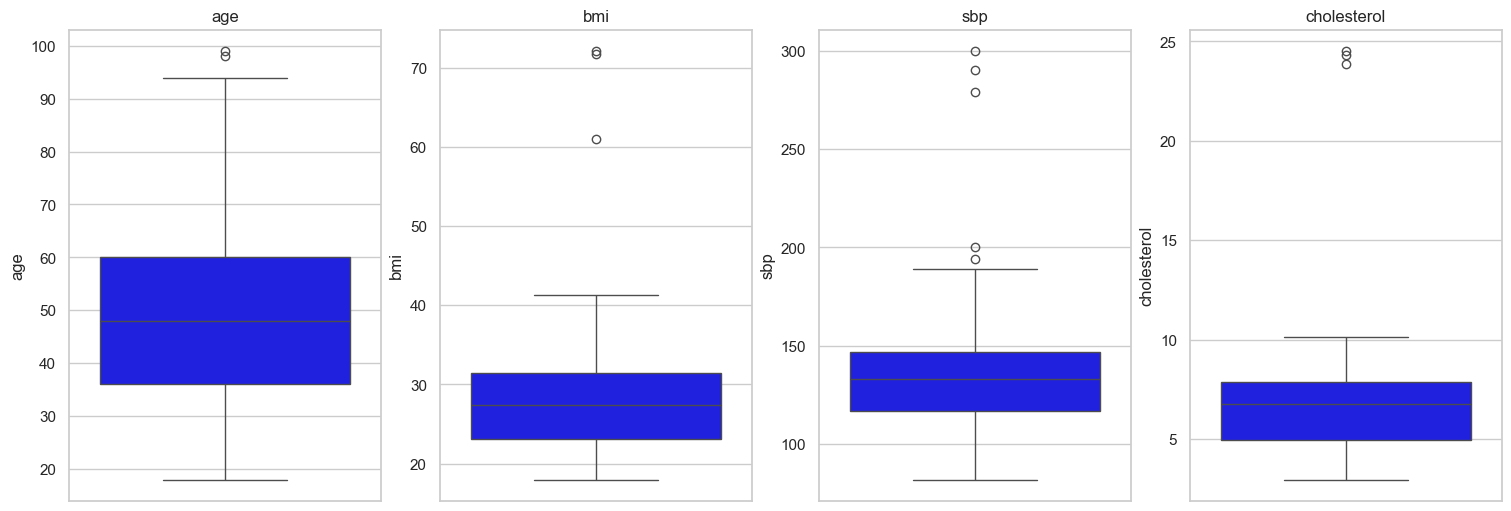

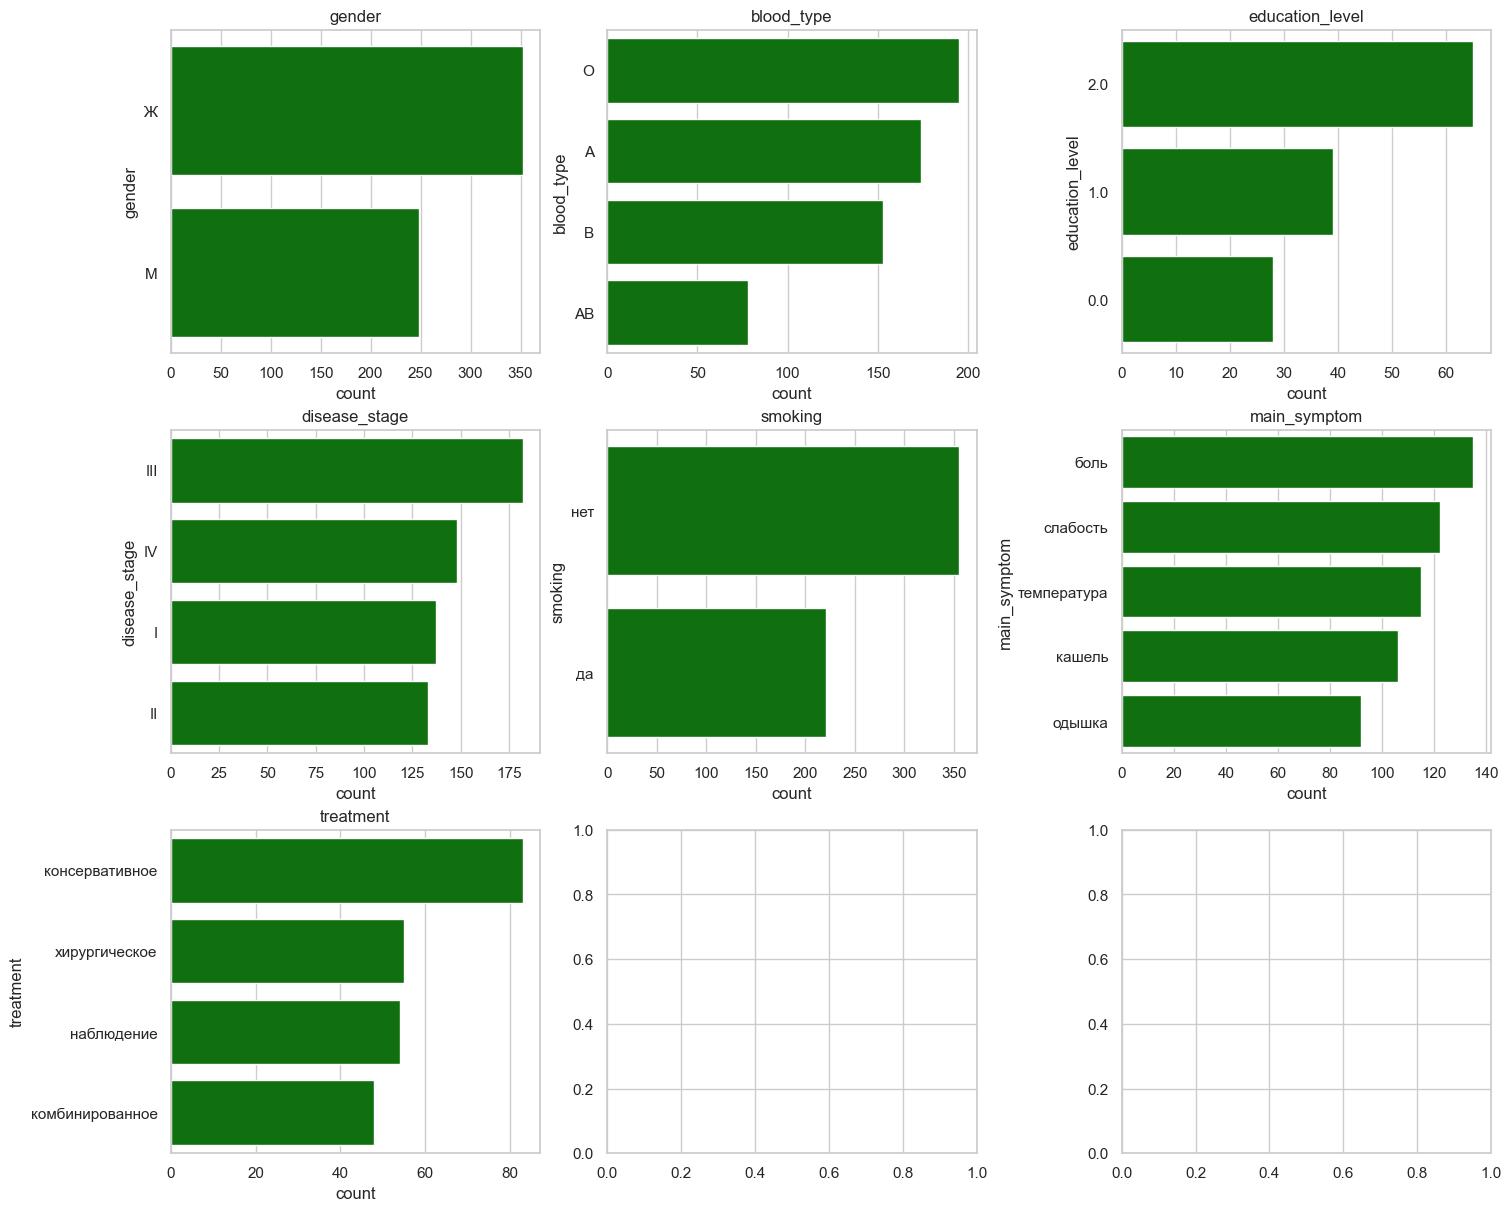

In [6]:
# Графики для первичного анализа: боксплоты для числовых, столбчатые диаграммы для категориальных

fig, axes = plt.subplots(1, len(num_cols), figsize=(15,5), constrained_layout=True) #отступы
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df[c], ax=ax, color="blue")
    ax.set_title(c)
plt.show()

# Категориальные распределения
cols = 3
rows = 3
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), constrained_layout=True)
#axes 2*3
axes = np.array(axes).reshape(-1)

for i, c in enumerate(cat_cols):
    ax = axes[i]
    vc = df[c].value_counts(dropna=False).head(10) #10 самых частых
    sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax, color="green")
    ax.set_title(c)
    ax.set_xlabel("count")
    
plt.show()

In [7]:
# Обработка пропусков и выбросов.
# - Числовые: заполняем медианой.
# - Категориальные: заполняем модой (самым частым значением).
# - Выбросы: для числовых делаем клиппинг по правилу IQR (анализируем и ограничиваем влияние экстремумов).

df_clean = df.copy()

# Импутация (замена пропущенных)
for c in num_cols:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())

for c in cat_cols:
    mode = df_clean[c].mode(dropna=True) # nan игнорируется, несколько мол мб
    fill = mode.iloc[0] if len(mode) else "unknown"
    df_clean[c] = df_clean[c].fillna(fill)

# Клиппинг выбросов по IQR (межквартильный размах)
c# Клиппинг выбросов по IQR
clip_bounds = {}
for c in [c for c in num_cols if c in df_clean.columns]:
    q1 = df_clean[c].quantile(0.25)
    q3 = df_clean[c].quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    clip_bounds[c] = (lo, hi)
    df_clean[c] = df_clean[c].clip(lo, hi)

clip_bounds

{'age': (np.float64(0.0), np.float64(96.0)),
 'bmi': (np.float64(11.2), np.float64(43.2)),
 'sbp': (np.float64(72.0), np.float64(192.0)),
 'cholesterol': (np.float64(1.0299999999999994), np.float64(11.99))}

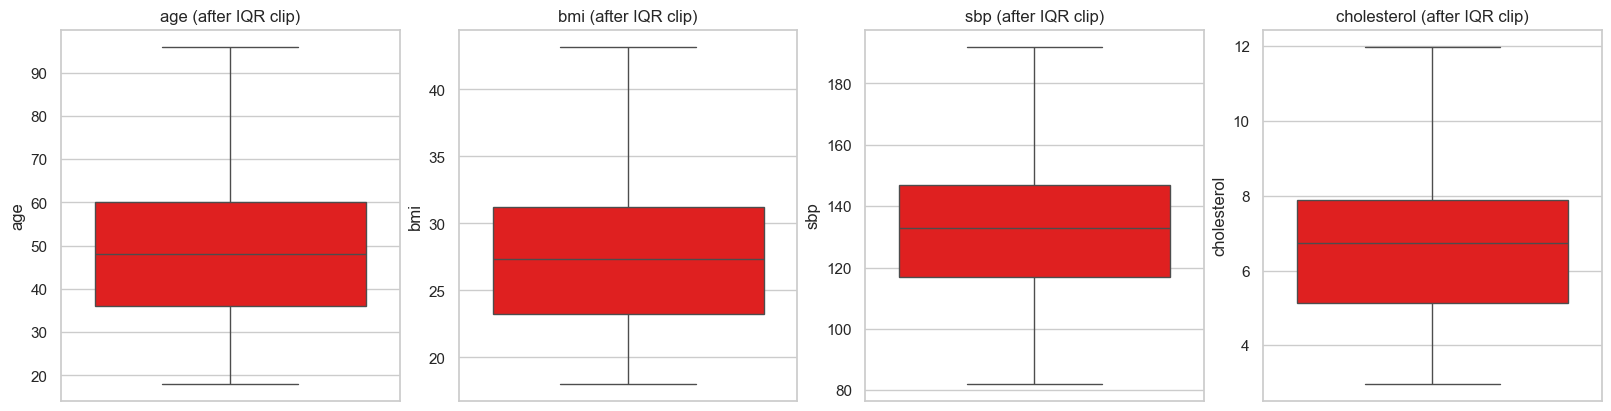

In [8]:
# Боксплоты после обработки выбросов (для сравнения)

fig, axes = plt.subplots(1, len(num_cols), figsize=(4*len(num_cols), 4), constrained_layout=True)
if len(num_cols) == 1:
    axes = [axes]
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df_clean[c], ax=ax, color="red")
    ax.set_title(f"{c} (after IQR clip)")
plt.show()

In [9]:
# Кодирование категориальных признаков и нормализация для кластеризации.
# Чтобы K-means/агломеративная кластеризация могли работать:
# - категориальные признаки переводим в 0/1 (one-hot) через pandas.get_dummies
# - числовые нормализуем (StandardScaler), чтобы признаки были сопоставимы по масштабу
num_features = [c for c in num_cols if c in df_clean.columns]
cat_features = [c for c in cat_cols if c in df_clean.columns]

# 1) Числовые (после нашей импутации и клиппинга они уже без NaN)
X_num = df_clean[num_features].astype(float).to_numpy()
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# 2) Категориальные: one-hot
X_cat = pd.get_dummies(df_clean[cat_features], drop_first=False)

# 3) Итоговая матрица признаков для кластеризации
X = np.hstack([X_num_scaled, X_cat.to_numpy(dtype=float)])

print("Числовых признаков:", len(num_features))
print("One-hot признаков:", X_cat.shape[1])
print("Итоговая матрица X:", X.shape)

Числовых признаков: 4
One-hot признаков: 22
Итоговая матрица X: (600, 26)


2) Визуализируйте данные на плоскости применив метод главных компонент (PCA). На основе графика предположите, сколько кластеров существует в данных?

Доля объяснённой дисперсии (PC1, PC2): [0.3515 0.0939]


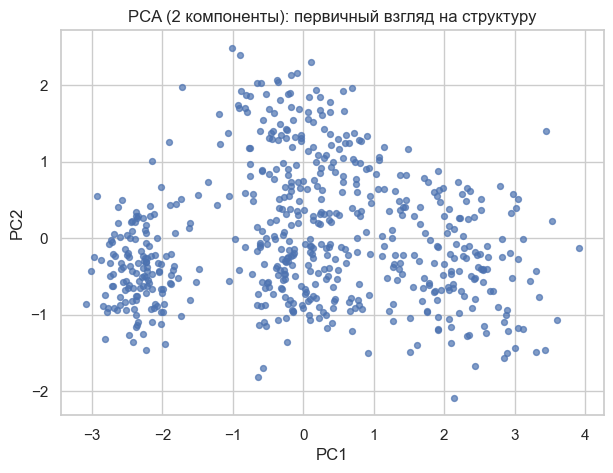

In [10]:
# 2) PCA-визуализация


pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X)

print("Доля объяснённой дисперсии (PC1, PC2):", np.round(pca2.explained_variance_ratio_, 4))

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=18, alpha=0.7)
plt.title("PCA (2 компоненты): первичный взгляд на структуру")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

похже на 3 кластера

In [11]:
# 3) K-means + проверка гипотез между кластерами
# Для числовых признаков: тест Краскела–Уоллиса.
# Для категориальных: хи-квадрат по таблице сопряжённости.

def cluster_significance_tests(df_for_tests: pd.DataFrame, labels: np.ndarray, alpha: float = 0.05):
    out_rows = []
    tmp = df_for_tests.copy()
    tmp["cluster"] = labels

    # числовые
    for c in num_cols:
        groups = [g[c].values for _, g in tmp.groupby("cluster")]
        stat, p = kruskal(*groups)
        out_rows.append({"feature": c, "type": "numeric", "p_value": p})

    # категориальные
    for c in cat_cols:
        ct = pd.crosstab(tmp["cluster"], tmp[c])
        chi2, p, dof, exp = chi2_contingency(ct)
        out_rows.append({"feature": c, "type": "categorical", "p_value": p})

    res = pd.DataFrame(out_rows).sort_values("p_value")
    res["significant"] = res["p_value"] < alpha
    return res

k_candidates = range(2, 7)
rows = []

for k in k_candidates:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)

    sil = silhouette_score(X, labels)
    tests = cluster_significance_tests(df_clean[num_cols + cat_cols], labels)
    n_sig = int(tests["significant"].sum())
    sizes = pd.Series(labels).value_counts().sort_index().to_list()

    rows.append({
        "k": k,
        "n_significant_features_(p<0.05)": n_sig,
        "cluster_sizes": sizes,
    })

summary_km = pd.DataFrame(rows).sort_values(["n_significant_features_(p<0.05)"], ascending=False)
summary_km

,k,n_significant_features_(p<0.05),cluster_sizes
1,3,10,"[162, 290, 148]"
2,4,10,"[135, 146, 156, 163]"
3,5,10,"[81, 146, 147, 163, 63]"
4,6,10,"[64, 95, 145, 70, 87, 139]"
0,2,7,"[300, 300]"


5 кластера оптимально

In [12]:
kmeans = KMeans(n_clusters=5, n_init=20, random_state=42)
labels_km = kmeans.fit_predict(X)

tests_km = cluster_significance_tests(df_clean[num_cols + cat_cols], labels_km)
tests_km.head(15)

,feature,type,p_value,significant
7,disease_stage,categorical,1.170215e-121,True
0,age,numeric,3.130487e-100,True
3,cholesterol,numeric,7.879542e-98,True
2,sbp,numeric,1.163854e-87,True
1,bmi,numeric,3.702153e-80,True
9,main_symptom,categorical,7.843860e-37,True
10,treatment,categorical,4.503386e-11,True
8,smoking,categorical,2.029593e-09,True
4,gender,categorical,3.246040e-04,True
5,blood_type,categorical,3.765065e-04,True


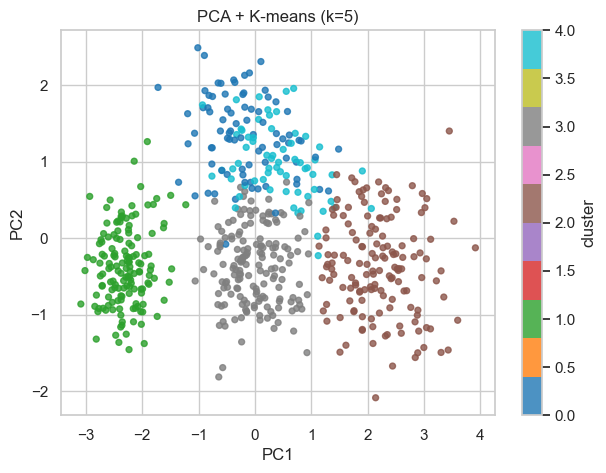

In [13]:
# PCA-проекция с цветами кластеров K-means

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap="tab10", s=18, alpha=0.8)
plt.title(f"PCA + K-means (k={5})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster")
plt.show()

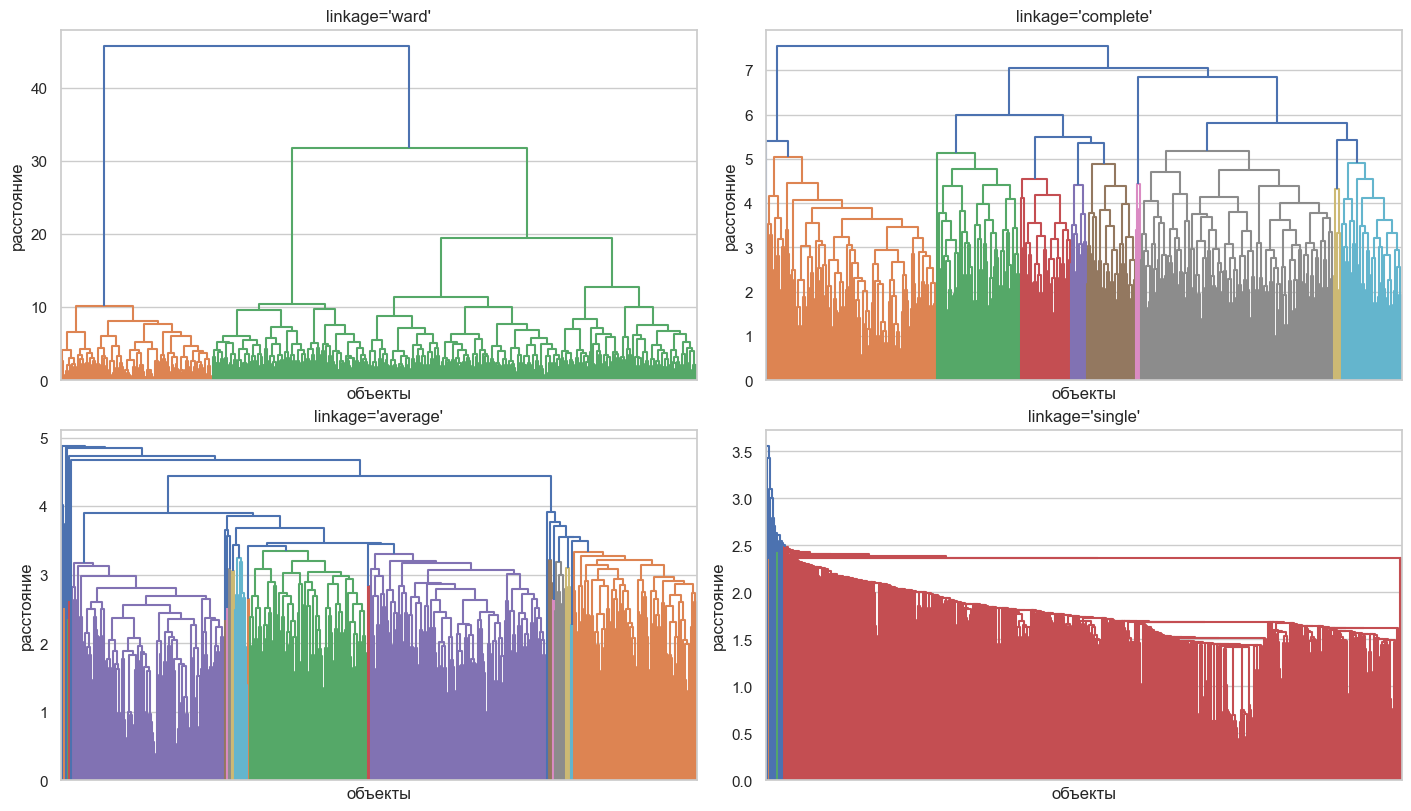

,method,cluster_sizes,min_cluster,max_cluster,max/min
0,ward,"[143, 147, 182, 56, 72]",56,182,3.25
1,complete,"[161, 79, 109, 5, 246]",5,246,49.20
2,average,"[4, 2, 2, 591, 1]",1,591,591.00
3,single,"[2, 595, 1, 1, 1]",1,595,595.00


In [14]:
# 4) Дендрограммы разными методами связи
# Дальше используем иерархическую кластеризацию (дендрограммы),
# поэтому сравним несколько способов "связи" (linkage).

# Про "сбалансированность":
# - грубая, но понятная оценка: если разрезать дендрограмму на k кластеров,
#   то чем ближе размеры кластеров друг к другу, тем "сбалансированнее" разбиение.

methods = ["ward", "complete", "average", "single"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
axes = axes.ravel()

linkages = {}
for ax, m in zip(axes, methods):
    Z = linkage(X, method=m)
    linkages[m] = Z
    dendrogram(Z, no_labels=True, ax=ax)
    ax.set_title(f"linkage='{m}'")
    ax.set_xlabel("объекты")
    ax.set_ylabel("расстояние")

plt.show()

# Сравним баланс кластеров при разрезе на k_opt (k выбрали в K-means)
balance_rows = []
for m in methods:
    cl = fcluster(linkages[m], t=5, criterion="maxclust")
    sizes = pd.Series(cl).value_counts().sort_index()
    balance_rows.append({
        "method": m,
        "cluster_sizes": sizes.to_list(),
        "min_cluster": int(sizes.min()),
        "max_cluster": int(sizes.max()),
        "max/min": float(sizes.max() / sizes.min()),
    })

balance = pd.DataFrame(balance_rows).sort_values("max/min")
balance

5) Примените к исходным предобработанным данным (не PCA-трансформированным) алгоритм агломеративной кластеризации с выбранным на предыдущем шаге методом оценки связи. Выберите оптимальное число кластеров на основе анализа дендрограммы и статистических различией между кластерами. После выбора окончательного числа кластеров визуализируйте данные на плоскости, применив PCA и изобразив точки разными цветами в зависимости от номера кластера.

In [15]:
best_linkage = balance.iloc[0]["method"]
print("Выбранный (наиболее сбалансированный) linkage:", best_linkage)

# 5) Агломеративная кластеризация с выбранным linkage.
# По заданию кластеризацию делаем на X (не PCA),
# а число кластеров подбираем, чтобы были статистически значимые различия.

def agglom_labels_for_k(k: int, linkage_method: str):
    # В AgglomerativeClustering мы задаём число кластеров напрямую.
    model = AgglomerativeClustering(n_clusters=k, linkage=linkage_method, metric="euclidean")
    return model.fit_predict(X)

rows = []
for k in range(2, 7):
    labels = agglom_labels_for_k(k, best_linkage)

    # Silhouette — вспомогательная метрика качества кластеризации
    sil = silhouette_score(X, labels)

    # Главное по заданию — проверка статистических различий между кластерами
    tests = cluster_significance_tests(df_clean[num_cols + cat_cols], labels)
    n_sig = int(tests["significant"].sum())

    sizes = pd.Series(labels).value_counts().sort_index().to_list()
    rows.append({
        "k": k,
        "n_significant_features_(p<0.05)": n_sig,
        "cluster_sizes": sizes,
    })

summary_ag = pd.DataFrame(rows).sort_values(
    ["n_significant_features_(p<0.05)"],
    ascending=False,
)
summary_ag

Выбранный (наиболее сбалансированный) linkage: ward


,k,n_significant_features_(p<0.05),cluster_sizes
2,4,11,"[128, 182, 147, 143]"
3,5,11,"[182, 143, 147, 72, 56]"
4,6,11,"[147, 143, 113, 72, 56, 69]"
0,2,9,"[457, 143]"
1,3,9,"[310, 143, 147]"


4 оптимально

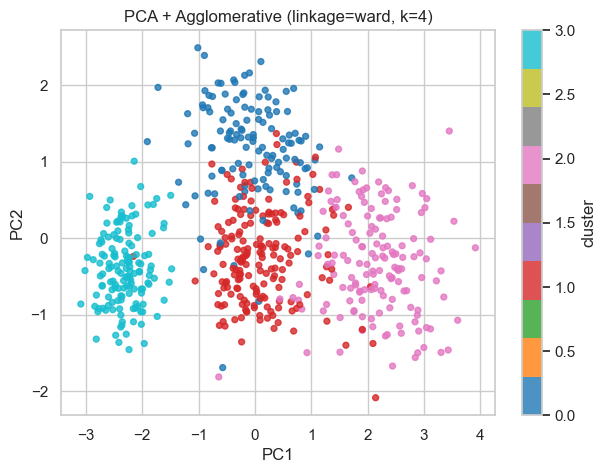

In [16]:
# PCA-проекция с цветами кластеров Agglomerative
k_opt_ag = int(summary_ag.iloc[0]["k"])
labels_ag = agglom_labels_for_k(k_opt_ag, best_linkage)

tests_ag = cluster_significance_tests(df_clean[num_features + cat_features], labels_ag)
tests_ag.head(15)
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_ag, cmap="tab10", s=18, alpha=0.8)
plt.title(f"PCA + Agglomerative (linkage={best_linkage}, k={k_opt_ag})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster")
plt.show()

6)класетры похожи

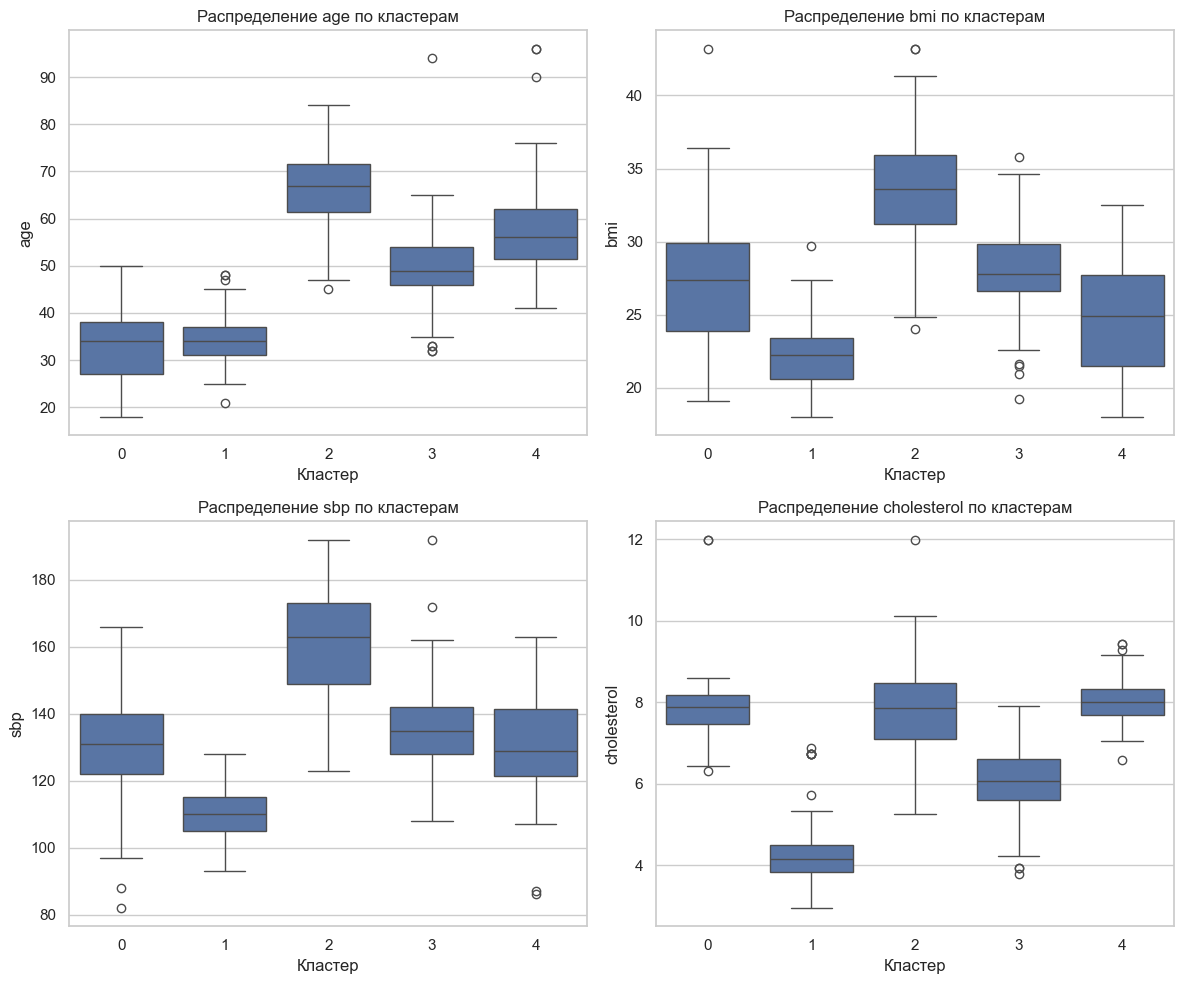

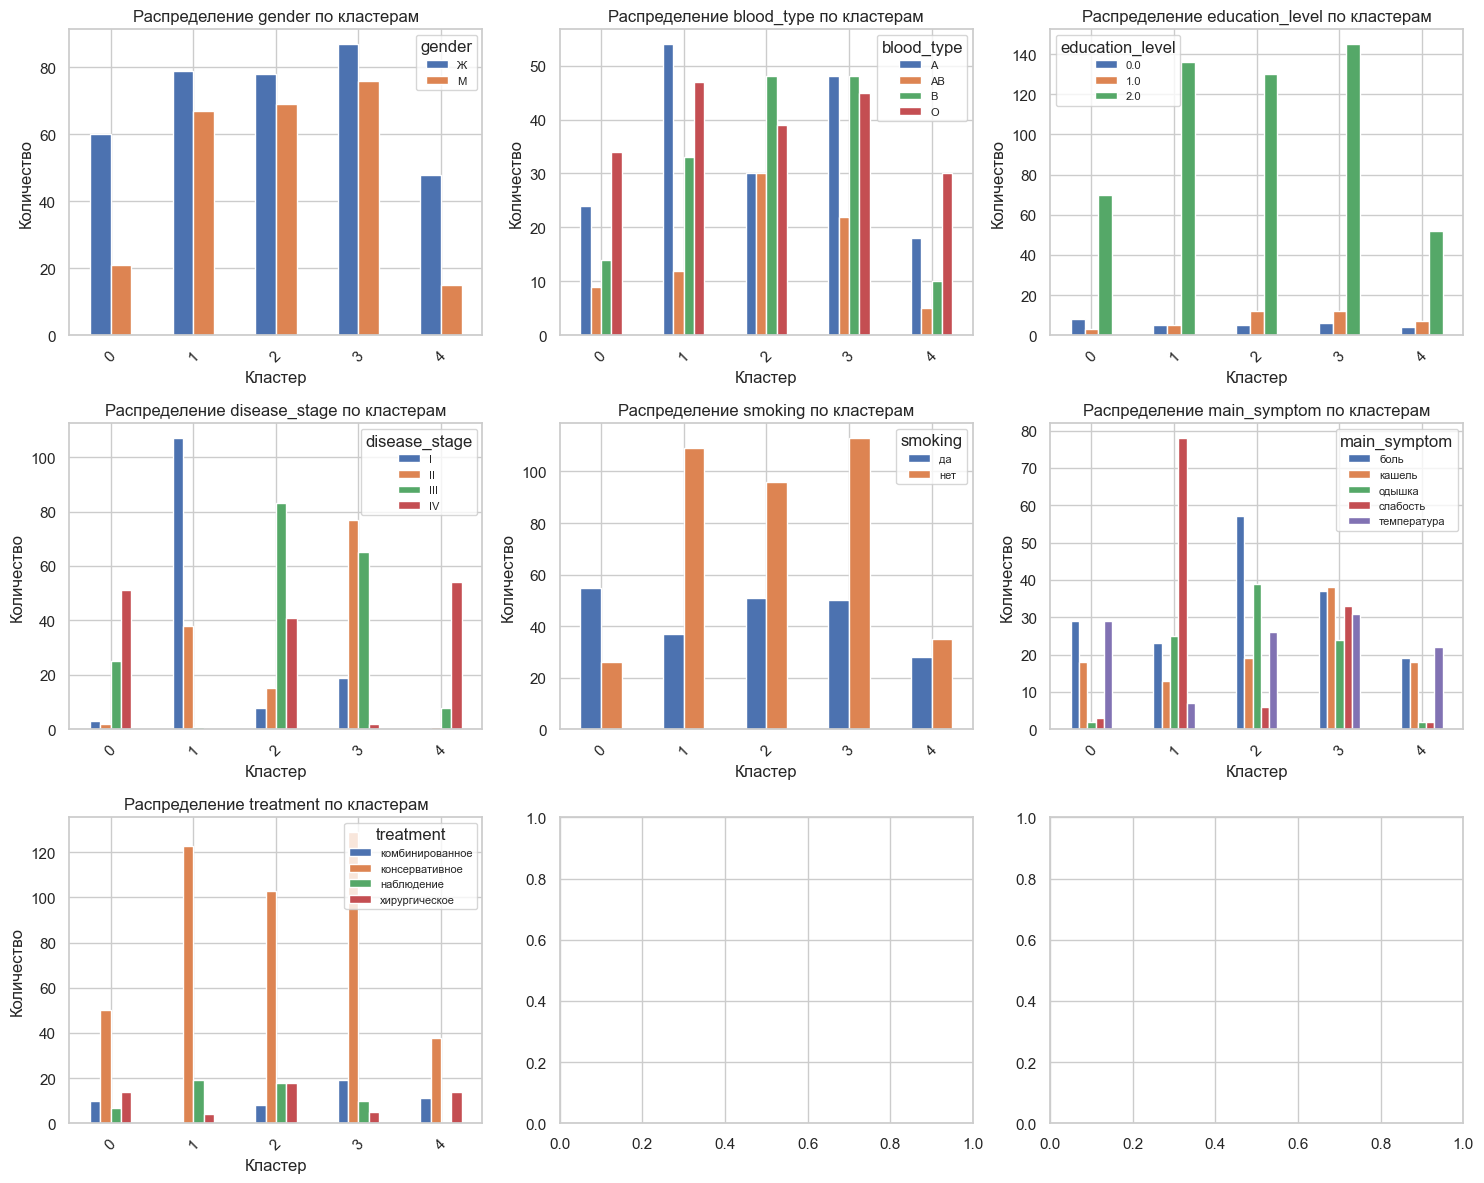

Размеры кластеров:
cluster_kmeans
0     81
1    146
2    147
3    163
4     63
Name: count, dtype: int64

Средние значения числовых признаков по кластерам:
                  age    bmi     sbp  cholesterol
cluster_kmeans                                   
0               32.46  27.20  129.86         7.87
1               34.30  22.19  110.44         4.26
2               66.49  33.71  161.49         7.88
3               50.32  28.08  135.29         6.07
4               58.14  24.71  129.87         8.02

Наиболее значимые признаки для разделения кластеров:
         feature        p_value
7  disease_stage  1.170215e-121
0            age  3.130487e-100
3    cholesterol   7.879542e-98
2            sbp   1.163854e-87
1            bmi   3.702153e-80


In [19]:
# 7) Характеристика кластеров - простые графики

# Создаем DataFrame с метками кластеров для анализа
df_profile = df_clean.copy()
df_profile['cluster_kmeans'] = labels_km

# Боксплоты для числовых признаков по кластерам
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(data=df_profile, x='cluster_kmeans', y=col, ax=ax)
    ax.set_title(f'Распределение {col} по кластерам')
    ax.set_xlabel('Кластер')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

# Столбчатые диаграммы для категориальных признаков по кластерам
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    # Создаем таблицу сопряженности
    ct = pd.crosstab(df_profile['cluster_kmeans'], df_profile[col])
    
    # Строим столбчатую диаграмму
    ct.plot(kind='bar', ax=ax)
    ax.set_title(f'Распределение {col} по кластерам')
    ax.set_xlabel('Кластер')
    ax.set_ylabel('Количество')
    ax.legend(title=col, fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Основные характеристики кластеров
print("Размеры кластеров:")
print(df_profile['cluster_kmeans'].value_counts().sort_index())

print("\nСредние значения числовых признаков по кластерам:")
print(df_profile.groupby('cluster_kmeans')[num_cols].mean().round(2))

print("\nНаиболее значимые признаки для разделения кластеров:")
print(tests_km.head(5)[['feature', 'p_value']])

ошибки - нет масштабирования, нет в подготовке данных отчистки дубликатов строк